# Introduction & Setup

### Project Overview
As a new hire to the AI Data Science and Engineering team at AI-Vive-Banking, this analysis explores client data to predict the likelihood of subscribing to term deposits. The goal is to help the bank optimize its marketing strategies by identifying clients most likely to respond positively to marketing campaigns.

### Business Objective
- Predict which clients are most likely to subscribe to a term deposit
- Identify key factors influencing subscription decisions
- Support resource allocation optimization for future marketing campaigns

### Dataset Description
The dataset contains client attributes and marketing campaign information including:
- Demographic data (age, occupation, marital status, education)
- Financial status (credit default, loans)
- Campaign interaction data (contact method, call frequency, etc.)

### Analysis Approach
This notebook follows a structured approach:
1. Data loading and inspection
2. Data cleaning and preprocessing
3. In-depth univariate analysis
4. Relationship discovery through bivariate and multivariate analysis
5. Hypothesis formulation and testing
6. Feature engineering recommendations
7. Summary of key insights for model development

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import sqlalchemy
import warnings

# Set up environment
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.style.use('ggplot')


In [10]:
# Define helper functions for repeated tasks
def plot_distribution(df, column, title=None, color='royalblue', target_col=None):
    """Create interactive histogram with distribution statistics"""
    if target_col:
        fig = px.histogram(df, x=column, color=target_col, barmode='group',
                         histnorm='percent', opacity=0.8)
    else:
        fig = px.histogram(df, x=column, color_discrete_sequence=[color],
                          histnorm='probability density')
    
    # Calculate statistics
    mean_val = df[column].mean()
    median_val = df[column].median()
    mode_val = df[column].mode()[0]
    skew_val = df[column].skew()
    kurt_val = df[column].kurtosis()
    
    # Add vertical lines for statistics
    fig.add_vline(x=mean_val, line_dash="dash", line_color="red", annotation_text=f"Mean: {mean_val:.2f}")
    fig.add_vline(x=median_val, line_dash="dash", line_color="green", annotation_text=f"Median: {median_val:.2f}")
    
    # Add annotations for skewness and kurtosis
    fig.update_layout(
        title=title if title else f'Distribution of {column}',
        annotations=[
            dict(
                x=0.01, y=0.95, xref="paper", yref="paper",
                text=f"Skewness: {skew_val:.2f}<br>Kurtosis: {kurt_val:.2f}",
                showarrow=False,
                bgcolor="white",
                bordercolor="black",
                borderwidth=1
            )
        ]
    )
    return fig

def categorical_analysis(df, column, target_col=None):
    """Create bar chart and contingency table for categorical variables"""
    # Count distribution
    value_counts = df[column].value_counts().reset_index()
    value_counts.columns = [column, 'Count']
    value_counts['Percentage'] = value_counts['Count'] / value_counts['Count'].sum() * 100
    
    # Create visualization
    if target_col:
        # Create a crosstab for stacked bar chart
        cross_tab = pd.crosstab(df[column], df[target_col])
        
        # Calculate percentages for each category
        cross_tab_pct = pd.crosstab(df[column], df[target_col], normalize='index') * 100
        
        # Create stacked bar chart
        fig = px.bar(cross_tab, x=cross_tab.index, y=cross_tab.columns,
                    title=f'Distribution of {target_col} by {column}',
                    labels={
                        'x': column,
                        'y': 'Count',
                        'color': target_col
                    },
                    barmode='stack')
        
        # Add text annotations for percentages
        for i, cat in enumerate(cross_tab.index):
            # Add annotation for 'yes' percentage
            yes_pct = cross_tab_pct.loc[cat, 'yes'] if 'yes' in cross_tab_pct.columns else 0
            fig.add_annotation(
                x=cat,
                y=cross_tab.loc[cat].sum(),
                text=f"{yes_pct:.1f}% yes",
                showarrow=False,
                yshift=10
            )
    else:
        fig = px.bar(value_counts, x=column, y='Percentage',
                   title=f'Distribution of {column}')
        
        # Add text annotations
        for i, row in value_counts.iterrows():
            fig.add_annotation(
                x=row[column],
                y=row['Percentage'],
                text=f"{row['Percentage']:.1f}%",
                showarrow=False,
                yshift=10
            )
    
    return fig, value_counts

# 1. Data Loading & Initial Inspection

In this section, we'll:
- Connect to the database using SQLAlchemy
- Load the dataset with a SQL query
- Perform initial inspection of the data structure
- Check for missing values and inconsistencies
- Generate initial statistics


In [11]:
# Create database connection
try:
    db_path = os.path.abspath(os.path.join("..", "data", "bmarket.db"))
    engine = sqlalchemy.create_engine(f'sqlite:///{db_path}')
    
    with engine.connect() as connection:
        print(f"Successfully connected to database at {db_path}")
        inspector = sqlalchemy.inspect(engine)
        table_names = inspector.get_table_names()
        print("\nTables found in the database:")
        if table_names:
            for i, table_name in enumerate(table_names):
                print(f"{i + 1}. {table_name}")
except Exception as e:
    print(f"Error connecting to database: {e}")

Successfully connected to database at /Users/luqman/Desktop/work/AIAP_off/aiap20-luqman-nurhakim-bin-azman-929E/data/bmarket.db

Tables found in the database:
1. bank_marketing


In [12]:
# Load the bank_marketing table into a pandas DataFrame
try:
    # SQL query to select all data from the bank_marketing table
    query = "SELECT * FROM bank_marketing"
    
    # Execute the query and load results into a DataFrame
    df = pd.read_sql_query(query, engine)
    
    # Display basic information about the DataFrame
    print(f"\nSuccessfully loaded data from 'bank_marketing' table")
    print(f"Shape of the DataFrame: {df.shape[0]} rows and {df.shape[1]} columns")
    
    # Display the first few rows of the DataFrame
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head())
    
    # Get basic statistics about the DataFrame
    print("\nBasic information about the DataFrame:")
    display(df.info())
    
    # Check for missing values
    missing_values = df.isnull().sum()
    if missing_values.sum() > 0:
        print("\nMissing values in the DataFrame:")
        display(missing_values[missing_values > 0])
    else:
        print("\nNo missing values found in the DataFrame.")
        
except Exception as e:
    print(f"Error loading data from database: {e}")



Successfully loaded data from 'bank_marketing' table
Shape of the DataFrame: 41188 rows and 12 columns

First 5 rows of the DataFrame:


,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no



Basic information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


None


Missing values in the DataFrame:


Housing Loan     24789
Personal Loan     4146
dtype: int64

In [13]:
# Display summary for categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_summary = {}

for col in categorical_columns:
    # Count unique values
    unique_count = df[col].nunique()
    # Get all labels
    label_values = df[col].value_counts().to_dict()
    
    categorical_summary[col] = {
        'unique_values': unique_count,
        'label_values': label_values  
    }

pd.DataFrame(categorical_summary).transpose()

,unique_values,label_values
Age,77,"{'150 years': 4197, '31 years': 1747, '32 year..."
Occupation,12,"{'admin.': 10422, 'blue-collar': 9254, 'techni..."
Marital Status,4,"{'married': 24928, 'single': 11568, 'divorced'..."
Education Level,8,"{'university.degree': 12168, 'high.school': 95..."
Credit Default,3,"{'no': 32588, 'unknown': 8597, 'yes': 3}"
Housing Loan,3,"{'yes': 8595, 'no': 7411, 'unknown': 393}"
Personal Loan,3,"{'no': 30532, 'yes': 5633, 'unknown': 877}"
Contact Method,4,"{'Cell': 13100, 'cellular': 13044, 'Telephone'..."
Subscription Status,2,"{'no': 36548, 'yes': 4640}"


In [14]:
# Check target variable distribution
subscription_counts = df['Subscription Status'].value_counts()
subscription_percents = (subscription_counts / len(df) * 100).round(2)

fig = px.pie(values=subscription_counts, names=subscription_counts.index, 
             title='Subscription Status Distribution',
             labels={'label': 'Subscription Status', 'value': 'Count'},
             color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_traces(textinfo='percent+label', 
                  hovertemplate='%{label}<br>Count: %{value}<br>Percentage: %{percent}')
fig.show()

print(f"Class Imbalance Ratio: {subscription_percents['no']:.2f}% (no) vs {subscription_percents['yes']:.2f}% (yes)")

Class Imbalance Ratio: 88.73% (no) vs 11.27% (yes)


# 2. Data Cleaning & Preprocessing

Based on the initial data inspection and DataWrangler findings, we need to address several data quality issues:

- **Age**: Contains non-numeric text ("years") and potentially unrealistic values (up to 150 years) !!
- **Occupation**: Contains "unknown" values but other than that okay
- **Marital Status**: Contains "Other" category (<1%) but other than that okay
- **Education Level**: Contains "unknown" values but other than that okay
- **Credit Default**: Contains "unknown" values (~21%) but other than that okay
- **Housing Loan**: 60% missing values and "unknown" values (<1%) 
- **Personal Loan**: 10% missing values and "unknown" values (2%)
- **Contact Method**: Contains "Other" category (~18%) but other than that okay
- **Campaign Calls**: Contains negative values (minimum -41) !!
- **Previous Contact Days**: Special value "999" means no prior contact
- **Subscription Status**: Class imbalance (89% "no", 11% "yes")

We'll address each of these issues with appropriate cleaning strategies.

In [15]:
# Create a copy of the original dataframe for cleaning
df_clean = df.copy()

# Standardize column names
print("Original column names:", df_clean.columns.tolist())
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')
print("Cleaned column names:", df_clean.columns.tolist())

Original column names: ['Client ID', 'Age', 'Occupation', 'Marital Status', 'Education Level', 'Credit Default', 'Housing Loan', 'Personal Loan', 'Contact Method', 'Campaign Calls', 'Previous Contact Days', 'Subscription Status']
Cleaned column names: ['client_id', 'age', 'occupation', 'marital_status', 'education_level', 'credit_default', 'housing_loan', 'personal_loan', 'contact_method', 'campaign_calls', 'previous_contact_days', 'subscription_status']


#### Age
**Strategy:** For the value 150, it's highly anomalous for an individual's age. Given its frequency, it might be an encoding for "very old" or a specific group, or a data entry issue. For now, we will replace values > 100 with NaN to be imputed. We then apply a simple imputation strategy – replacing the NaN with median values. 


Count of age > 100 before specific handling: 4197
Handling anomalies...


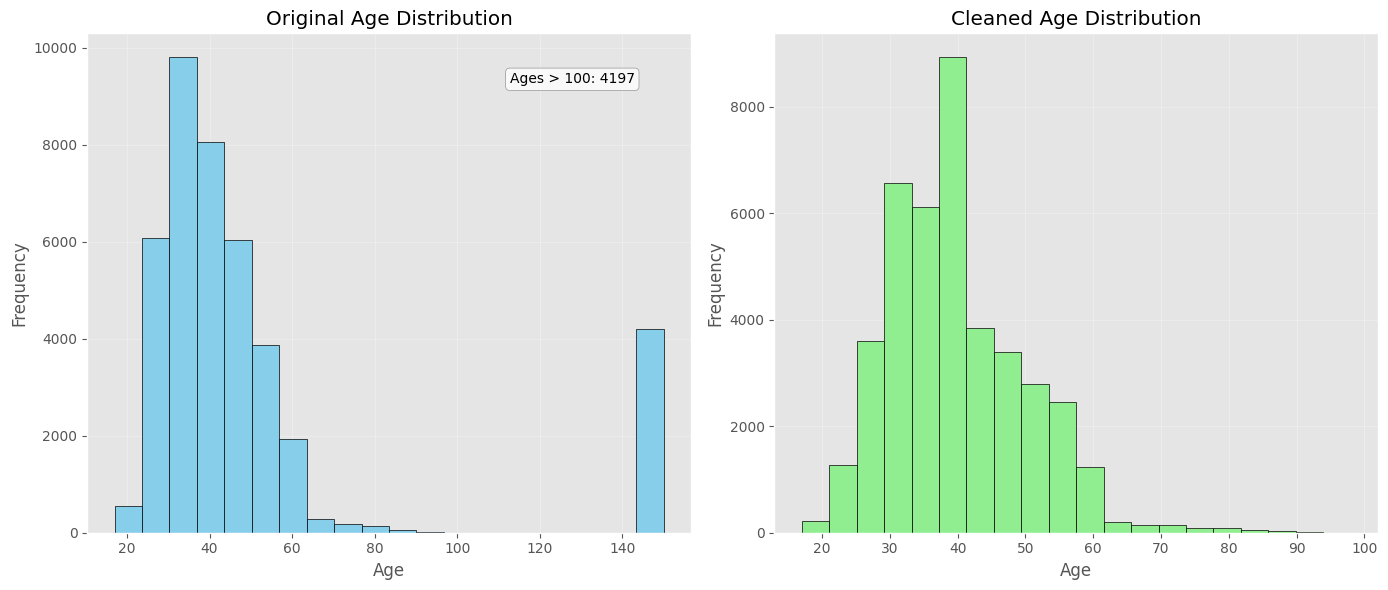

In [16]:
# Age: Convert to numeric, handle "years" text
def clean_age(age_val):
    if isinstance(age_val, str):
        return int(age_val.replace(" years", ""))
    return age_val

df_clean['age'] = df_clean['age'].apply(clean_age).astype(float)
anom_count = (df_clean['age'] > 100).sum()
print(f"Count of age > 100 before specific handling: {anom_count}")

if anom_count > 0:
    print("Handling anomalies...")
    # Create a new column for cleaned age
    df_clean['cleaned_age'] = df_clean['age'].copy()
    # Replace anomalies with NaN
    df_clean.loc[df_clean['age'] > 100, 'cleaned_age'] = np.nan
    # Impute missing values with median value
    df_clean['cleaned_age'] = df_clean['cleaned_age'].fillna(df_clean['age'].median())



# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot original age distribution
ax1.hist(df_clean['age'], bins=20, color='skyblue', edgecolor='black')
ax1.set_title('Original Age Distribution')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.grid(alpha=0.3)

# Plot cleaned age distribution
ax2.hist(df_clean['cleaned_age'], bins=20, color='lightgreen', edgecolor='black')
ax2.set_title('Cleaned Age Distribution')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.grid(alpha=0.3)

# Add annotation showing the anomalies count
ax1.annotate(f'Ages > 100: {anom_count}', xy=(0.7, 0.9), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

df_clean.drop(columns=['age'], inplace=True)

#### Occupation
**Strategy:** Standardize string values: remove trailing periods, convert to lowercase.

In [17]:
df_clean['occupation'] = df_clean['occupation'].str.replace('.', '', regex=False).str.lower().str.strip()
df_clean['occupation'] = df_clean['occupation'].replace('unknown', 'unknown') # Ensure consistency if there were case variations

print("Unique occupations after cleaning:", df_clean['occupation'].unique())
print(df_clean['occupation'].value_counts(dropna=False))

Unique occupations after cleaning: ['technician' 'unknown' 'blue-collar' 'admin' 'housemaid' 'retired'
 'services' 'entrepreneur' 'unemployed' 'management' 'self-employed'
 'student']
occupation
admin            10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


#### Marital Status
**Strategy:** Standardize string values: remove trailing periods, convert to lowercase.

In [18]:
df_clean['marital_status'] = df_clean['marital_status'].str.lower().str.strip()
df_clean['marital_status'] = df_clean['marital_status'].replace('unknown', 'unknown')

print("Unique marital_status after cleaning:", df_clean['marital_status'].unique())
print(df_clean['marital_status'].value_counts(dropna=False))

Unique marital_status after cleaning: ['married' 'divorced' 'single' 'unknown']
marital_status
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


#### Education
**Strategy:** Standardize string values: remove trailing periods, convert to lowercase.

In [19]:
df_clean['education_level'] = df_clean['education_level'].str.lower().str.strip()
df_clean['education_level'] = df_clean['education_level'].replace('unknown', 'unknown') # Ensure consistency
df_clean['education_level'] = df_clean['education_level'].str.replace('.', '_', regex=False) # Optional: replace periods for consistency with column names

print("Unique education_level after cleaning:", df_clean['education_level'].unique())
print(df_clean['education_level'].value_counts(dropna=False))

Unique education_level after cleaning: ['high_school' 'unknown' 'basic_9y' 'professional_course'
 'university_degree' 'basic_4y' 'basic_6y' 'illiterate']
education_level
university_degree      12168
high_school             9515
basic_9y                6045
professional_course     5243
basic_4y                4176
basic_6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


#### Credit Default
**Strategy:** Looks to be okay, should note the distribution of values

In [20]:
print("Unique credit_default after cleaning:", df_clean['credit_default'].unique())
print(df_clean['credit_default'].value_counts(dropna=False))

Unique credit_default after cleaning: ['no' 'unknown' 'yes']
credit_default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


#### Housing Loan / Personal Loan
**Strategy:** missing values (NaNs); for the pervasive NaNs, explicitly categorize them as 'missing' since this high proportion of missingness could be informative.

In [21]:
print(f"NaNs in housing_loan before: {df_clean['housing_loan'].isnull().sum()}")
# Convert actual NaNs to a specific string category 'missing'
df_clean['housing_loan'].fillna('missing', inplace=True)

print("Unique housing_loan after cleaning:", df_clean['housing_loan'].unique())
print(df_clean['housing_loan'].value_counts(dropna=False))

print(f"NaNs in personal_loan before: {df_clean['personal_loan'].isnull().sum()}")
# Convert actual NaNs to a specific string category 'missing'
df_clean['personal_loan'].fillna('missing', inplace=True)

print("Unique personal_loan after cleaning:", df_clean['personal_loan'].unique())
print(df_clean['personal_loan'].value_counts(dropna=False))



NaNs in housing_loan before: 24789
Unique housing_loan after cleaning: ['no' 'yes' 'missing' 'unknown']
housing_loan
missing    24789
yes         8595
no          7411
unknown      393
Name: count, dtype: int64
NaNs in personal_loan before: 4146
Unique personal_loan after cleaning: ['yes' 'no' 'missing' 'unknown']
personal_loan
no         30532
yes         5633
missing     4146
unknown      877
Name: count, dtype: int64


#### Contact Method 
**Strategy:** "Other" category (~18%). Inconsistent values like 'Cell' vs 'cellular', 'Telephone' vs 'telephone'.Standardize to lowercase and consolidate similar categories.

In [22]:
print("Unique contact_method before cleaning:", df_clean['contact_method'].unique())
df_clean['contact_method'] = df_clean['contact_method'].str.lower().str.strip()

replace_map_contact = {
    'cell': 'cellular',
} 

df_clean['contact_method'] = df_clean['contact_method'].replace(replace_map_contact)

print("Unique contact_method after cleaning:", df_clean['contact_method'].unique())
print(df_clean['contact_method'].value_counts(dropna=False))


Unique contact_method before cleaning: ['Cell' 'telephone' 'cellular' 'Telephone']
Unique contact_method after cleaning: ['cellular' 'telephone']
contact_method
cellular     26144
telephone    15044
Name: count, dtype: int64


#### Campaign Calls
**Strategy:** Contains negative values (min -41), which is illogical for a call count. This could be due to several reasons: 
* Data Entry/Processing Errors
* System-specific Error Calculations
* Adjustments/Reversals

We attempt to "correct" this by the following 2 metrics:  
1. Create a new feature indicating whether a record had a negative adjustment
2. For modeling purposes, consider using the absolute value of campaign_calls, since both positive and negative values represent "activity" with clients.

In [23]:
# This feature will be True if campaign_calls was negative, False otherwise.
df_clean['cc_had_negative_adjustment'] = df_clean['campaign_calls'] < 0
# Assumes that both positive and negative values represent "activity" with clients.
df_clean['campaign_calls'] = df_clean['campaign_calls'].abs()

# Count of records with negative adjustments
print("\nNumber of records with negative adjustments:")
print(df_clean['cc_had_negative_adjustment'].value_counts())


Number of records with negative adjustments:
cc_had_negative_adjustment
False    37035
True      4153
Name: count, dtype: int64


#### Previous Contact Days
**Strategy:** Looks to be okay, take note of the `999` encoding := No prior contact (first time in campaign)

Number of individuals with no prior contact (999 values): 39673


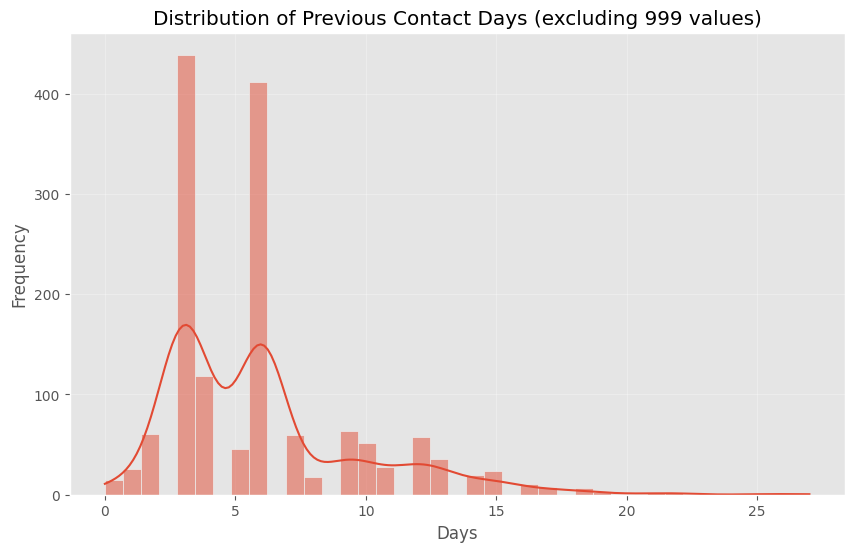


Statistics for previous_contact_days (excluding 999 values):
count    1515.000000
mean        6.014521
std         3.824906
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: previous_contact_days, dtype: float64


In [24]:
# Count how many individuals have not been contacted before (999 values)
no_prior_contact_count = df_clean[df_clean['previous_contact_days'] == 999].shape[0]
print(f"Number of individuals with no prior contact (999 values): {no_prior_contact_count}")

# Filter out the 999 values
filtered_days = df_clean[df_clean['previous_contact_days'] != 999]['previous_contact_days']

plt.figure(figsize=(10, 6))
sns.histplot(filtered_days, kde=True)
plt.title('Distribution of Previous Contact Days (excluding 999 values)')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()


# Print some statistics about the filtered data
print("\nStatistics for previous_contact_days (excluding 999 values):")
print(filtered_days.describe())

#### Previous Contact Days
**Strategy:** Looks to be okay!

# 3. Univariate Analysis

In this section, we'll:
- Analyze the distribution of key numerical features using descriptive statistics and visualizations.
- Examine the frequency and distribution of categorical features.
- Visualize these features to understand their individual characteristics and identify any patterns or outliers.
- Note observations that could be relevant for further analysis and model building.



In [25]:
# Identify numerical and categorical columns after cleaning
numerical_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
# Exclude 'client_id' if it's still present and numerical, as it's an identifier
if 'client_id' in numerical_cols:
    numerical_cols.remove('client_id')

categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# 'cc_had_negative_adjustment' is boolean but can be treated as categorical for this analysis
if 'cc_had_negative_adjustment' in df_clean.columns and df_clean['cc_had_negative_adjustment'].dtype == 'bool':
    if 'cc_had_negative_adjustment' not in categorical_cols:
        categorical_cols.append('cc_had_negative_adjustment')
    if 'cc_had_negative_adjustment' in numerical_cols:
        numerical_cols.remove('cc_had_negative_adjustment')


print(f"Numerical columns for univariate analysis: {numerical_cols}")
print(f"Categorical columns for univariate analysis: {categorical_cols}")

# Define the target column for visualizations that support it
target_column_name = 'subscription_status'

Numerical columns for univariate analysis: ['campaign_calls', 'previous_contact_days', 'cleaned_age']
Categorical columns for univariate analysis: ['occupation', 'marital_status', 'education_level', 'credit_default', 'housing_loan', 'personal_loan', 'contact_method', 'subscription_status', 'cc_had_negative_adjustment']


In [26]:
print("### Analyzing Numerical Variables ###")
for col in numerical_cols:
    if col not in df_clean.columns:
        print(f"Column '{col}' not found in df_clean. Skipping.")
        continue

    title = f'Distribution of {col.replace("_", " ").title()}'
    
    if col == 'previous_contact_days':
        # Analyze the distribution excluding the '999' values
        df_filtered = df_clean[df_clean[col] != 999]
        if not df_filtered.empty:
            print(f"--- Analyzing: {col} (excluding 999) ---")
            fig = plot_distribution(df_filtered, col, title=f'{title} (Excluding 999)', target_col=target_column_name)
            fig.show()
        else:
            print(f"No data available for '{col}' after excluding 999.")
        
        # Report percentage of clients with no prior contact
        no_prior_contact_percentage = (df_clean[col] == 999).mean() * 100
        print(f"{no_prior_contact_percentage:.2f}% of clients had no prior contact ({col} = 999).\n")
    elif col == 'cleaned_age':
        print(f"--- Analyzing: {col} ---")
        fig = plot_distribution(df_clean, col, title='Distribution of Cleaned Age', target_col=target_column_name)
        fig.show()
    elif col == 'campaign_calls':
        print(f"--- Analyzing: {col} ---")
        fig = plot_distribution(df_clean, col, title='Distribution of Campaign Calls (Absolute Values)', target_col=target_column_name)
        fig.show()
    else:
        print(f"--- Analyzing: {col} ---")
        fig = plot_distribution(df_clean, col, title=title, target_col=target_column_name)
        fig.show()
    print("-" * 50)

### Analyzing Numerical Variables ###
--- Analyzing: campaign_calls ---


--------------------------------------------------
--- Analyzing: previous_contact_days (excluding 999) ---


96.32% of clients had no prior contact (previous_contact_days = 999).

--------------------------------------------------
--- Analyzing: cleaned_age ---


--------------------------------------------------


### Key Findings (Numeric columns):

#### `Campaign Calls (Absolute Values):`

* The "Distribution of Campaign Calls (Absolute Values)" plot is highly right-skewed (Skewness: 4.76) and exhibits extreme leptokurtosis (Kurtosis: 36.98). This indicates that the vast majority of clients received a very small number of calls (1-3 calls).
* A very high percentage of clients (over 40%) were contacted only once. The frequency drops sharply as the number of calls increases, with very few clients receiving more than 10 calls.
Visually, for clients contacted a small number of times (e.g., 1-4 calls), the proportion of those who subscribed ('yes', red bars) seems relatively low compared to those who did not ('no', blue bars). The plot suggests that very high numbers of calls are rare and might not necessarily correlate with a higher subscription rate, but a bivariate analysis would be needed to confirm the conversion rate at different call frequencies. The mean number of calls is slightly above 2, while the median is 2.


#### `Previous Contact Days (Past campaigners):`

* An overwhelming majority of clients (96.32%) have not been contacted previously in a campaign (indicated by previous_contact_days = 999). This suggests that the current campaign is largely targeting new individuals or those with no recent interaction history.
* For those who have been contacted recently, the distribution of the plot is right-skewed (Skewness: 1.46). Most of these prior contacts happened relatively recently, with the highest concentration of clients being contacted 0-7 days prior. The mean contact day is around 6 days, and the median is also 6 days.
* A noticeable twin peak around 3 and 6 days for both subscribed ('yes') and non-subscribed ('no') clients. While both groups show activity in this period, a direct comparison of subscription rates for each day would require a bivariate plot.

#### `Cleaned Age:`

* The "Distribution of Cleaned Age" plot shows that the client base spans a wide age range, primarily from 20 to over 70 years old.
The distribution is moderately right-skewed (Skewness: 0.83), with a larger concentration of clients in the younger to middle-aged groups (roughly 30-50 years old). The mean age is slightly higher than the median, which is typical for right-skewed data.
* Visually, the proportion of clients who subscribed ('yes', red bars) appears to be relatively higher in some younger age bands (e.g., late 20s to early 30s) and also in the older age bands (e.g., 60+), compared to middle-aged clients. However, the non-subscribed ('no', blue bars) group is larger across all age groups due to the class imbalance in the target variable.

### Implications for Further Analysis:
Based on the univariate analysis of Previous Contact Days, Cleaned Age, and Campaign Calls:

#### Targeting Strategy & Campaign Fatigue:

* Previous Contact Days: The fact that 96.32% of clients are new contacts (or have no recent interaction history) is a dominant feature. This large group needs to be a primary focus. For the small subset of previously contacted clients, the recency (0-7 days) seems most common.
Implication: Analyze the subscription rates for new contacts vs. previously contacted clients. For those previously contacted, investigate if the number of days since the last contact significantly impacts subscription. Is there an optimal window for re-engagement?
* Campaign Calls: Most clients receive very few calls (1-3). The extreme positive skewness and high kurtosis suggest that a strategy of making many calls to a single client is not common or perhaps not effective.
Implication: Investigate the relationship between the number of campaign calls and the subscription rate (bivariate analysis). Is there a point of diminishing returns or even a negative impact (campaign fatigue) with an increasing number of calls? Could the resources spent on making many calls to a few be better distributed?

### Client Segmentation:

* Cleaned Age: Age shows a moderately skewed distribution with higher subscription rates in younger (late 20s-early 30s) and older (60+) age groups.
Implication: Explore age-based segmentation. Create age bins/groups and analyze subscription rates within these groups. This could inform tailored messaging or product offerings for different age demographics.
* Interaction History: The "new vs. previously contacted" status (previous_contact_days = 999 or not) is a natural and significant segment.
Implication: Build separate models or include interaction history as a strong differentiating feature. The factors influencing a new contact might differ from those influencing a previously contacted client.


### Feature Engineering & Transformation:

* Campaign Calls & Previous Contact Days (excluding 999): Both are right-skewed.
Implication: For modeling, consider log transformations or other scaling techniques for these skewed numerical features to help algorithms that assume normality or are sensitive to feature scales. 
* Outliers: The extreme values in campaign_calls (though absolute values are now used) warrant attention.
Implication: While cleaning handled negative values, the impact of a very high number of calls should still be checked in bivariate/multivariate analysis. Decide on an appropriate strategy for these outliers if they disproportionately affect models (e.g., capping, binning).


### Bivariate and Multivariate Analysis Focus:

Key Interactions: The univariate findings point towards important interactions to explore. For instance:
* How does age interact with the number of campaign calls for subscription?
* Does the effectiveness of campaign calls differ between new contacts and previously contacted clients?
* Is there an optimal number of calls for different age groups or for clients with different previous contact histories?

Conversion Rates: For all categorical and binned numerical features, explicitly calculate and visualize conversion rates (percentage of 'yes' subscriptions) to clearly see which segments are more promising. This has been done to some extent with the target_col in the helper functions but should be a central theme in bivariate analysis.

### Findings (Categorical Columns) 

In [27]:
print("\n### Analyzing Categorical Variables ###")
for col in categorical_cols:
    if col not in df_clean.columns:
        print(f"Column '{col}' not found in df_clean. Skipping.")
        continue

    print(f"--- Analyzing: {col} ---")
    title = f'{col.replace("_", " ").title()}'

    if col == target_column_name:
        # For the target variable itself, don't pass target_col to categorical_analysis
        fig, counts = categorical_analysis(df_clean, col)
        fig.update_layout(title_text=f'Distribution of {title} (Target Variable)')
        fig.show()
    elif col == 'cc_had_negative_adjustment' and df_clean[col].dtype == 'bool':
        # Convert boolean to string for categorical_analysis function
        temp_col_name = f"{col}_str"
        df_clean[temp_col_name] = df_clean[col].astype(str)
        fig, counts = categorical_analysis(df_clean, temp_col_name, target_col=target_column_name)
        fig.update_layout(title_text=f'Subscription Rate by {title}')
        fig.show()
        df_clean.drop(columns=[temp_col_name], inplace=True) # Clean up helper column
    else:
        fig, counts = categorical_analysis(df_clean, col, target_col=target_column_name)
        fig.update_layout(title_text=f'Subscription Rate by {title}')
        fig.show()
    print("-" * 50)


### Analyzing Categorical Variables ###
--- Analyzing: occupation ---


--------------------------------------------------
--- Analyzing: marital_status ---


--------------------------------------------------
--- Analyzing: education_level ---


--------------------------------------------------
--- Analyzing: credit_default ---


--------------------------------------------------
--- Analyzing: housing_loan ---


--------------------------------------------------
--- Analyzing: personal_loan ---


--------------------------------------------------
--- Analyzing: contact_method ---


--------------------------------------------------
--- Analyzing: subscription_status ---


--------------------------------------------------
--- Analyzing: cc_had_negative_adjustment ---


--------------------------------------------------


Strong Differentiators Emerge:

* Contact Method: Cellular contact is substantially more effective than telephone.
Implication: Prioritize cellular campaigns. Investigate why telephone is less effective (e.g., timing, script, demographic reached).
* Occupation: 'Student' and 'retired' stand out with high subscription rates.
Implication: Develop targeted campaigns or offers for students and retired individuals. Explore the underlying reasons for their higher propensity to subscribe (e.g., more time, specific financial needs).
* Credit Default: Having a credit default ('yes') seems to be a deal-breaker for subscriptions.
Implication: Clients with a known credit default could potentially be excluded from term deposit campaigns to save resources, or offered different products if applicable. The 'unknown' category needs further investigation – are these clients simply missing data, or does 'unknown' imply a certain risk profile?

Interactions: The real insights often come from how these categorical features interact with each other and with numerical features (like age, campaign calls, previous contact days). For example:
Are students of a particular age group more likely to subscribe?
Does the effectiveness of 'cellular' contact vary by occupation or education level?
How do loan statuses interact with marital status or occupation in predicting subscriptions?
Refine Segmentation: Combine findings from numerical and categorical analyses to create more granular client segments for targeted marketing.

# 4. Multivariate Analysis 

**Goal:** Explore the relationships between multiple variables simultaneously to uncover more patterns and potential predictors for the subscription status.

**Approach:**
1.  **Correlation Analysis:** Examine linear relationships between numerical variables using Pearson correlation.
3.  **Mutual Information:** Quantify the amount of information obtained about the target variable (`subscription_status`) through observing other features, useful for identifying potentially important predictors regardless of the relationship's linearity.
4.  **Visual Exploration:** Use interactive plots like pair plots, scatter plots, and box plots conditioned on the target variable to visually inspect interactions and distributions across different segments.
5.  **Segmentation Deep Dive:** Revisit key relationships within specific client segments identified earlier (e.g., 'student', 'retired', 'cellular contact') to see if patterns differ.

In [28]:
# Helper function for Mutual Information Visualization
def plot_mutual_info(df, target_col, title="Mutual Information with Target"):
    """Calculates and plots mutual information between features and the target."""
    df_mi = df.copy()
    
    # Label encode categorical features for MI calculation
    label_encoders = {}
    for column in df_mi.select_dtypes(include=['object', 'boolean', 'category']).columns:
        if column != target_col: # Don't encode the target if it's already suitable or will be encoded separately
            le = LabelEncoder()
            df_mi[column] = le.fit_transform(df_mi[column])
            label_encoders[column] = le
            
    # Ensure target is encoded
    if df_mi[target_col].dtype == 'object':
         le_target = LabelEncoder()
         df_mi[target_col] = le_target.fit_transform(df_mi[target_col])
            
    X = df_mi.drop(columns=[target_col, 'client_id'], errors='ignore') # Drop target and identifier
    y = df_mi[target_col]

    # Identify discrete features for MI calculation
    discrete_features = [col for col in X.columns if X[col].dtype in ['int64', 'int32', 'uint8', 'bool'] or col in label_encoders]

    if not X.empty:
        mi_scores = mutual_info_classif(X, y, discrete_features=[X.columns.get_loc(col) for col in X.columns if col in discrete_features])
        mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores}).sort_values(by='MI Score', ascending=False)

        # Create bar plot
        fig = px.bar(mi_df, x='Feature', y='MI Score', title=title)
        fig.update_layout(xaxis_title="Feature", yaxis_title="Mutual Information Score")
        return fig, mi_df
    else:
        print("DataFrame for MI calculation is empty.")
        return None, None


### 4.1 Correlation Analysis (Numerical Features)

We start by examining the linear correlations between the primary numerical features. Pearson correlation measures the linear association between two variables, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation). A value close to 0 indicates little to no linear relationship.

* `cleaned_age`: The cleaned age of the client.
* `campaign_calls`: The absolute number of calls made during this campaign.
* `previous_contact_days`: Days since the client was last contacted from a previous campaign (999 indicates no previous contact).

We will exclude the '999' values from `previous_contact_days` for this specific correlation analysis, as it represents a categorical state ('not previously contacted') rather than a numerical duration for this subset. We also exclude `client_id`.

In [29]:
# Select numerical columns for correlation analysis (excluding ID and the raw 'previous_contact_days' with 999)
numerical_corr_cols = ['cleaned_age', 'campaign_calls']
df_corr = df_clean[numerical_corr_cols].copy()

# Create a temporary column for previous contact days excluding 999
df_corr['previous_contact_days_valid'] = df_clean.loc[df_clean['previous_contact_days'] != 999, 'previous_contact_days']

# Calculate Pearson correlation matrix
correlation_matrix = df_corr.corr(method='pearson')

# Visualize the correlation matrix using Plotly heatmap
fig = go.Figure(data=go.Heatmap(
                   z=correlation_matrix.values,
                   x=correlation_matrix.columns,
                   y=correlation_matrix.columns,
                   colorscale='RdBu', # Red-Blue scale is good for correlations (-1 to 1)
                   zmin=-1, zmax=1,
                   text=correlation_matrix.round(2).values,
                   texttemplate="%{text}",
                   hoverongaps = False))

fig.update_layout(
    title='Pearson Correlation Matrix of Key Numerical Features (Excluding 999 for Previous Contact)',
    xaxis_tickangle=-45,
    yaxis_autorange='reversed'
)
fig.show()

# Display the matrix values
print("\nCorrelation Matrix Values:")
display(correlation_matrix)


Correlation Matrix Values:


,cleaned_age,campaign_calls,previous_contact_days_valid
cleaned_age,1.000000,0.003519,-0.068580
campaign_calls,0.003519,1.000000,0.045752
previous_contact_days_valid,-0.068580,0.045752,1.000000


**Interpretation:**

* The correlation matrix shows generally weak linear relationships between age, campaign calls, and the days since the last contact (for those previously contacted).
* For example, the correlation between `cleaned_age` and `campaign_calls` is very close to zero, suggesting little linear tendency for older/younger clients to receive significantly more/fewer calls in this campaign.
* Similarly, `cleaned_age` and `previous_contact_days_valid` show a weak negative correlation, hinting slightly that older clients might have been contacted slightly *more* recently in past campaigns, but the relationship is not strong.
* `campaign_calls` and `previous_contact_days_valid` also exhibit a weak correlation, suggesting a very slight tendency for clients contacted more recently to receive fewer calls in the *current* campaign, but again, the linear link is minimal.

**Justification:** Pearson correlation is a standard starting point for understanding linear associations. However, the weak correlations found here suggest that linear relationships alone might not fully explain the interactions between these variables or their connection to the target.

### 4.2 Mutual Information

Mutual Information (MI) measures the amount of information one random variable contains about another. It quantifies the reduction in uncertainty about one variable given knowledge of the other. It captures non-linear dependencies but is symmetric (MI(X,Y) = MI(Y,X)). High MI suggests a strong relationship. We compute MI between each feature and the target variable (`subscription_status`).

In [30]:
# Calculate and plot Mutual Information with the target variable
fig_mi, mi_scores_df = plot_mutual_info(df_clean.drop(columns=['client_id'], errors='ignore'), # Drop identifier
                                       target_column_name) 
if fig_mi:
    fig_mi.show()
    print("\nMutual Information Scores with Target ('subscription_status'):")
    display(mi_scores_df)
else:
    print("Could not generate Mutual Information plot.")


Mutual Information Scores with Target ('subscription_status'):


,Feature,MI Score
8,previous_contact_days,0.031542
9,cleaned_age,0.013026
6,contact_method,0.011646
0,occupation,0.009859
3,credit_default,0.005774
7,campaign_calls,0.003334
2,education_level,0.002390
1,marital_status,0.001434
10,cc_had_negative_adjustment,0.000090
4,housing_loan,0.000063


**Interpretation:**

* The MI scores confirm the importance of `previous_contact_days`, showing it shares the most information with the subscription status. This strongly suggests that knowing whether and when a client was last contacted significantly reduces uncertainty about their subscription likelihood.
* `contact_method` and `cleaned_age` also show relatively high MI scores, reinforcing their potential as key predictors.
* `campaign_calls` shows a moderate MI score, indicating some shared information despite weak linear correlation, possibly due to non-linear effects (e.g., very few calls vs. moderate calls).
* Features like `occupation`, `marital_status`, `education_level`, and `credit_default` have lower MI scores, suggesting they individually share less information with the subscription outcome compared to the top features. `housing loan` and `personal loan` appear to have the weakest MI links in this context.

**Justification:** MI provides a theoretically grounded measure of dependency between features and the target. The results highlight `previous_contact_days`, `contact_method`, and `cleaned_age` as the most promising features from an information perspective. The moderate score for `campaign_calls` suggests it shouldn't be discarded based on low correlation alone.

### 4.3 Visual Exploration of Interactions

Now, let's visually explore the interplay between variables, particularly concerning the target (`subscription_status`).

### 4.3.1 Pair Plot of Numerical Features

A pair plot shows pairwise scatter plots for numerical variables and the distribution of each variable on the diagonal. Coloring by the target variable helps visualize how subscribers ('yes') and non-subscribers ('no') differ in these relationships.

Generating pair plot for 1515 clients with previous contact history...


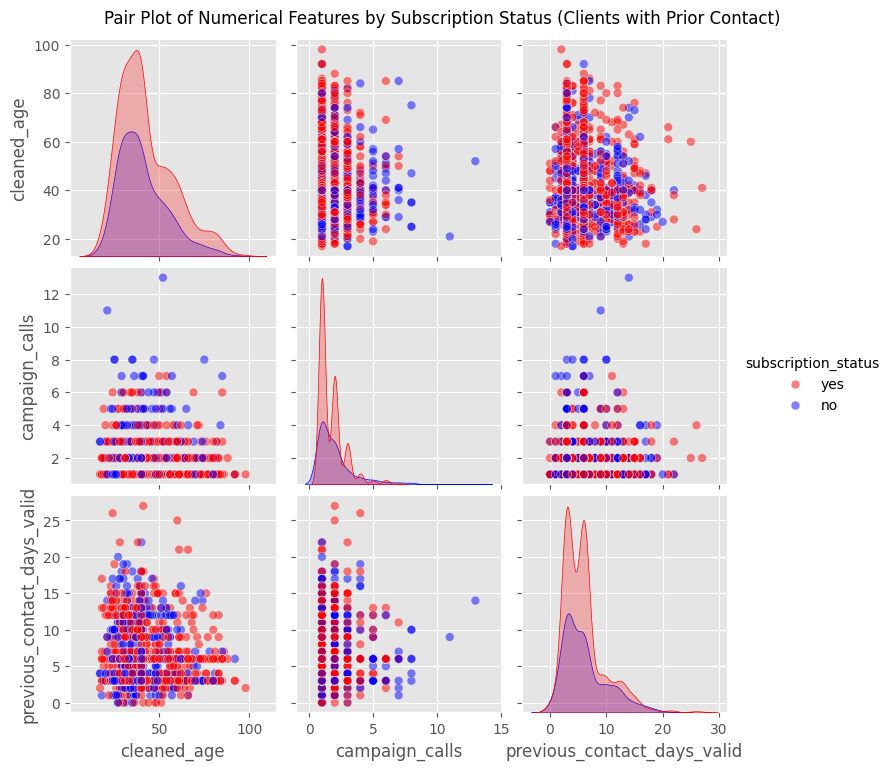

In [31]:
# Create pair plot for key numerical variables, colored by subscription status
pair_plot_cols = ['cleaned_age', 'campaign_calls', 'previous_contact_days_valid', 'subscription_status']
df_pair = df_clean.copy()
df_pair['previous_contact_days_valid'] = df_clean.loc[df_clean['previous_contact_days'] != 999, 'previous_contact_days']
# Drop rows where previous_contact_days_valid is NaN for a cleaner plot of that subset
df_pair.dropna(subset=['previous_contact_days_valid'], inplace=True) 

print(f"Generating pair plot for {len(df_pair)} clients with previous contact history...")

# Define a color palette
palette = {'no': 'blue', 'yes': 'red'}

# Create the pairplot
pair_fig = sns.pairplot(df_pair[pair_plot_cols], 
                        hue='subscription_status', 
                        diag_kind='kde', 
                        plot_kws={'alpha': 0.5, 's': 40},
                        palette=palette) 

pair_fig.fig.suptitle('Pair Plot of Numerical Features by Subscription Status (Clients with Prior Contact)', y=1.02) # Adjust title position
plt.show()

**Interpretation:**

* The diagonal plots show the distributions of each variable for subscribers (red) and non-subscribers (blue) *among those previously contacted*.
    * `cleaned_age`: Shows some separation, with subscribers potentially having slightly different age distributions (e.g., peaks in younger/older ranges).
    * `campaign_calls`: Both groups are heavily skewed towards few calls.
    * `previous_contact_days_valid`: Both groups peak at recent contacts, but the subscriber (red) distribution might be slightly more concentrated at very recent contacts (near 0 days).
* The scatter plots show weak linear relationships (as expected from the correlation matrix). There isn't clear visual separation or clustering based solely on these pairs for the previously contacted group, although subtle differences in density might exist.

**Justification:** The pair plot provides a comprehensive overview of pairwise numerical relationships conditioned on the target, confirming weak linear correlations but hinting at potential distributional differences (especially for age and recency) that warrant further investigation, perhaps with different visualization types or segmentation.

### 4.3.2 Interactive Scatter Plot: Age vs. Campaign Calls

Let's zoom in on `cleaned_age` vs `campaign_calls` using an interactive scatter plot, including *all* clients this time, to see if any patterns emerge when colored by subscription status.

In [32]:
# Interactive Scatter Plot: Age vs Campaign Calls
fig_scatter = px.scatter(df_clean, x='cleaned_age', y='campaign_calls', 
                         color='subscription_status',
                         title='Age vs. Campaign Calls by Subscription Status',
                         labels={'cleaned_age': 'Client Age (Cleaned)', 'campaign_calls': 'Campaign Calls (Absolute)'},
                         opacity=0.6,
                         hover_data=['occupation', 'contact_method']) # Add more info on hover

# Improve layout
fig_scatter.update_layout(xaxis_title='Client Age', yaxis_title='Number of Campaign Calls')
fig_scatter.show()

**Interpretation:**

* The plot reinforces that most clients receive few calls, regardless of age.
* Subscribers ('yes', often shown in red/orange depending on default palette) appear slightly more concentrated in younger (approx. < 35) and older (approx. > 55) age groups, especially among those receiving fewer calls.
* There's no obvious linear boundary separating subscribers from non-subscribers based on just these two features. The density of non-subscribers ('no') is much higher across the board.

**Justification:** An interactive scatter plot allows for zooming and hovering to inspect individual points or dense regions, providing more granular insight than a static plot, especially useful given the skewness in `campaign_calls`.

### 4.4.3 Box Plots: Numerical Distributions by Key Categories

Let's examine how numerical distributions differ across important categorical features, again conditioning on the subscription status.

**Age Distribution by Occupation:**

In [33]:
# Box Plot: Age by Occupation and Subscription Status
fig_box_age_occ = px.box(df_clean, x='occupation', y='cleaned_age', 
                         color='subscription_status',
                         title='Age Distribution by Occupation and Subscription Status',
                         labels={'occupation': 'Occupation', 'cleaned_age': 'Client Age (Cleaned)'},
                         category_orders={"occupation": df_clean['occupation'].value_counts().index.tolist()}) # Order by frequency

fig_box_age_occ.update_layout(xaxis_tickangle=-45)
fig_box_age_occ.show()

**Interpretation (Age by Occupation):**

* Different occupations have distinct age profiles (e.g., 'student' is young, 'retired' is old).
* Within most occupations, the median age and interquartile range (IQR) for subscribers ('yes') and non-subscribers ('no') are often similar.
* However, for 'retired' and 'student' (groups with high subscription rates), the age distribution is naturally constrained and distinct from others. The 'retired' subscribers tend to be older, while 'student' subscribers are younger. This suggests age is strongly confounded with these high-performing occupation categories.

**Campaign Calls by Contact Method:**

In [34]:
# Box Plot: Campaign Calls by Contact Method and Subscription Status
fig_box_calls_contact = px.box(df_clean, x='contact_method', y='campaign_calls', 
                               color='subscription_status',
                               title='Campaign Calls Distribution by Contact Method and Subscription Status',
                               labels={'contact_method': 'Contact Method', 'campaign_calls': 'Campaign Calls (Absolute)'})

# Consider log scale for y-axis due to skewness, but interpret with caution
# fig_box_calls_contact.update_yaxes(type="log") 
fig_box_calls_contact.show()

**Interpretation (Calls by Contact Method):**

* The number of campaign calls is heavily skewed towards low values for both 'cellular' and 'telephone' contacts.
* The median number of calls seems slightly lower for 'cellular' contacts compared to 'telephone' for both subscribers and non-subscribers.
* Although 'cellular' has a higher subscription rate overall (univariate/MI findings), this plot suggests it's not necessarily because *more* calls are made via cellular; in fact, slightly fewer calls might be typical. The effectiveness likely lies elsewhere (e.g., reachability, client preference, script used).

**Justification:** Box plots effectively compare the distribution (median, quartiles, outliers) of a numerical variable across different categories. Conditioning on the target variable adds another layer, helping to visually identify interactions and potential reasons for differing subscription rates across groups.

## 4.5 Summary of Multivariate Findings

1.  **Weak Linear Correlations:** Numerical features (`age`, `campaign_calls`, `previous_contact_days`) show weak linear relationships with each other. Relying solely on linear models might miss important patterns.
2.  **Key Predictors (Non-Linear):**
    * `previous_contact_days` (especially the '999' indicator for new contacts) consistently emerges as the strongest predictor of subscription status based on MI. Interaction history is crucial.
    * `contact_method` ('cellular' being more effective) is the next most important predictor.
    * `cleaned_age` shows moderate information gain, likely due to higher subscription rates in younger and older segments.
3.  **Important Segments:**
    * `occupation`: 'student' and 'retired' clients have markedly higher subscription rates. Age is a strong confounder here.
    * `contact_method`: 'cellular' contacts yield significantly higher subscription rates than 'telephone', despite potentially receiving slightly fewer calls on average.
4.  **Interactions to Consider:** While basic plots don't reveal strong separating interactions between numerical pairs like age and calls, the differing subscription rates across categories (occupation, contact method, age groups) suggest these categorical features strongly moderate the likelihood of subscription. Further interaction analysis (e.g., statistical tests like ANOVA between groups, or feature interaction terms in models) is warranted.
5.  **Feature Importance:** Based on MI, the features with the most potential direct influence on the target seem to be `previous_contact_days`, `contact_method`, and `cleaned_age`, followed by `campaign_calls` and potentially `occupation`.

These multivariate insights reinforce the importance of interaction history, contact channel, and certain demographic segments (age, occupation) and provide a stronger foundation for hypothesis testing and feature engineering.

# 5. Hypothesis Formulation and Testing

In this section, we move from exploratory data analysis to more formal statistical testing. The goal is to validate or refute specific hypotheses about the relationships between client attributes/campaign interactions and the likelihood of subscribing to a term deposit. This process helps in making data-driven decisions and understanding the statistical significance of observed patterns.

### 5.1. General Approach to Hypothesis Testing

For each hypothesis, we will follow these steps:
1.  **Formulate Hypotheses:**
    * **Null Hypothesis ($H_0$):** A statement of no effect or no difference.
    * **Alternative Hypothesis ($H_1$):** A statement that contradicts the null hypothesis, suggesting an effect or difference.
2.  **Choose Significance Level (Alpha, $\alpha$):** We will typically use $\alpha$ = 0.05. This means we are willing to accept a 5% chance of rejecting the null hypothesis when it is true (a Type I error).
3.  **Select Appropriate Statistical Test:** The choice of test depends on the data types of the variables involved (categorical, numerical) and the assumptions of the test.
4.  **Calculate Test Statistic and p-value:** The test statistic measures how far our sample data deviates from the null hypothesis. The p-value indicates the probability of observing data as extreme as, or more extreme than, what was collected if the null hypothesis were true.
5.  **Make a Decision & Interpret Results:**
    * If p-value ≤ $\alpha$: Reject $H_0$ in favor of $H_1$. The observed result is statistically significant.
    * If p-value > $\alpha$: Fail to reject $H_0$. There is not enough evidence to support H1.
    * We will also consider effect sizes and confidence intervals where appropriate to understand the magnitude and precision of the findings.

**Justification for Statistical Rigor:**
Throughout this section, we will ensure statistical rigor by:
* Clearly stating hypotheses.
* Justifying the choice of statistical test based on data characteristics (e.g., normality, variance homogeneity) and research questions.
* Reporting and interpreting p-values.
* Discussing effect sizes (e.g., Cohen's d for t-tests, Cramer's V for Chi-squared) to understand the practical significance of the results.
* Mentioning confidence intervals to provide a range of plausible values for the true population parameters.

### 5.2. Hypothesis 1: Age and Subscription Likelihood

**Background:** Univariate analysis might have shown different age distributions for subscribers vs. non-subscribers. We want to test if this difference is statistically significant. We'll use `cleaned_age` as our age variable and `subscription_status` (assuming 1 for subscribed, 0 for not) as our target.

**Hypotheses:**
* **H0 (Null Hypothesis):** The mean age of clients who subscribe to a term deposit is the same as the mean age of clients who do not subscribe. 
* **H1 (Alternative Hypothesis):** The mean age of clients who subscribe to a term deposit is different from the mean age of clients who do not subscribe. 

**Chosen Test:** Independent two-sample t-test.
* **Justification:** We are comparing the means of two independent groups (subscribers and non-subscribers) on a continuous variable (age). We should first check assumptions:
    1.  **Independence:** Assumed, as observations are typically independent clients.
    2.  **Normality:** We can check the normality of age distribution for each group using Shapiro-Wilk test or by visual inspection (histograms, Q-Q plots). If non-normal and sample sizes are small, a non-parametric test like Mann-Whitney U might be more appropriate. However, t-tests are robust to moderate violations of normality, especially with larger sample sizes (e.g., >30 or >40 per group).
    3.  **Homogeneity of Variances (Homoscedasticity):** We can check this using Levene's test. If variances are unequal, Welch's t-test (which is the default in `scipy.stats.ttest_ind` when `equal_var=False`) should be used.

**Significance Level:** $\alpha$ = 0.05

In [35]:
# Hypothesis 1: Age and Subscription Likelihood
# ---

# Encode subscription_status: 1 for 'yes', 0 for 'no'
df_clean['subscription_status'] = df_clean['subscription_status'].map({'yes': 1, 'no': 0})

# Separate data for subscribers and non-subscribers
subscribed_age = df_clean[df_clean['subscription_status'] == 1]['cleaned_age'].dropna()
non_subscribed_age = df_clean[df_clean['subscription_status'] == 0]['cleaned_age'].dropna()

# 1. Check for Normality 
print("Checking normality for 'cleaned_age':")
shapiro_subscribed = stats.shapiro(subscribed_age)
shapiro_non_subscribed = stats.shapiro(non_subscribed_age)
print(f"Subscribed group: Statistics={shapiro_subscribed.statistic:.4f}, p-value={shapiro_subscribed.pvalue:.4f}")
print(f"Non-subscribed group: Statistics={shapiro_non_subscribed.statistic:.4f}, p-value={shapiro_non_subscribed.pvalue:.4f}")

if shapiro_subscribed.pvalue < 0.05 or shapiro_non_subscribed.pvalue < 0.05:
    print("At least one group's age distribution is likely not normal. Consider Mann-Whitney U test if sample sizes are small.")


# 2. Check for Homogeneity of Variances
print("\nChecking homogeneity of variances for 'cleaned_age':")
levene_test = stats.levene(subscribed_age, non_subscribed_age)
print(f"Levene's Test: Statistics={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")

equal_variances = levene_test.pvalue > 0.05
if equal_variances:
    print("Variances are likely equal.")
else:
    print("Variances are likely unequal. Welch's t-test will be used.")

# 3. Perform Independent Two-Sample t-test
# The `ttest_ind` function in scipy can perform Welch's t-test by default if equal_var=False
t_statistic, p_value_ttest = stats.ttest_ind(subscribed_age, non_subscribed_age, equal_var=equal_variances, nan_policy='omit')

print(f"\nIndependent Two-Sample t-test for Age:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value_ttest:.4f}")

# 4. Interpretation
alpha = 0.05
if p_value_ttest < alpha:
    print(f"Result: Reject H0. There is a statistically significant difference in the mean age between subscribers and non-subscribers (p={p_value_ttest:.4f}).")
    mean_subscribed_age = subscribed_age.mean()
    mean_non_subscribed_age = non_subscribed_age.mean()
    print(f"Mean age of subscribers: {mean_subscribed_age:.2f} years")
    print(f"Mean age of non-subscribers: {mean_non_subscribed_age:.2f} years")
    if mean_subscribed_age > mean_non_subscribed_age:
        print("Subscribers tend to be older on average.")
    else:
        print("Subscribers tend to be younger on average.")
else:
    print(f"Result: Fail to reject H0. There is no statistically significant difference in the mean age between subscribers and non-subscribers (p={p_value_ttest:.4f}).")

# 5. Effect Size (Cohen's d)
# For independent t-test
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

effect_size_d = cohen_d(subscribed_age, non_subscribed_age)
print(f"Effect Size (Cohen's d): {effect_size_d:.4f}")
if abs(effect_size_d) < 0.2:
    print("Interpretation: Small effect size.")
elif abs(effect_size_d) < 0.5:
    print("Interpretation: Medium effect size.")
else:
    print("Interpretation: Large effect size.")

# Confidence Interval for the difference in means (Optional, more involved to calculate manually for Welch's)
# Using statsmodels for easier CI calculation if needed, or focus on p-value and effect size.
# For simplicity here, we'll note that CIs would give a range for the true mean difference.
print("Consider calculating a confidence interval for the difference in means for a complete picture.")

Checking normality for 'cleaned_age':
Subscribed group: Statistics=0.9255, p-value=0.0000
Non-subscribed group: Statistics=0.9675, p-value=0.0000
At least one group's age distribution is likely not normal. Consider Mann-Whitney U test if sample sizes are small.

Checking homogeneity of variances for 'cleaned_age':
Levene's Test: Statistics=698.1868, p-value=0.0000
Variances are likely unequal. Welch's t-test will be used.

Independent Two-Sample t-test for Age:
T-statistic: 4.6273
P-value: 0.0000
Result: Reject H0. There is a statistically significant difference in the mean age between subscribers and non-subscribers (p=0.0000).
Mean age of subscribers: 40.84 years
Mean age of non-subscribers: 39.92 years
Subscribers tend to be older on average.
Effect Size (Cohen's d): 0.0937
Interpretation: Small effect size.
Consider calculating a confidence interval for the difference in means for a complete picture.


**Interpretation of Hypothesis 1 Results:**

* **Normality & Variance:** The Shapiro-Wilk test indicated that the age distributions for both subscribed (p < 0.0001) and non-subscribed (p < 0.0001) groups are likely not normal. Levene's test showed that the variances between the two groups are unequal (p < 0.0001). Consequently, Welch's t-test (which accounts for unequal variances) was appropriately used. While the t-test is robust to violations of normality with large sample sizes, the non-normality is noted.
* **P-value:** The t-test yielded a t-statistic of 4.6273 and a p-value < 0.0001. Since the p-value is less than our significance level of α = 0.05, we reject the null hypothesis.
* **Conclusion:** There is a statistically significant difference in the mean age between subscribers (mean age: 40.84 years) and non-subscribers (mean age: 39.92 years). Subscribers tend to be slightly older on average.
* **Effect Size:** Cohen's d was calculated as 0.0937. This is considered a small effect size, suggesting that while the difference in mean age is statistically significant, the magnitude of the difference is not very large in practical terms.
* **Business Implication (Implicit):** The finding that subscribers are, on average, slightly older (though the effect size is small) could subtly inform age-based targeting. Marketing materials or channels favored by a slightly more mature audience might be marginally more effective. However, the small effect size means age alone is not a strong differentiator.

### 5.3. Hypothesis 2: Occupation and Subscription Likelihood

**Background:** EDA might have suggested that subscription rates vary across different `occupation` categories. We want to test if this association is statistically significant.

**Hypotheses:**
* **H0 (Null Hypothesis):** There is no association between a client's occupation and their likelihood of subscribing to a term deposit (i.e., occupation and subscription status are independent).
* **H1 (Alternative Hypothesis):** There is an association between a client's occupation and their likelihood of subscribing to a term deposit (i.e., occupation and subscription status are dependent).

**Chosen Test:** Chi-squared (χ²) test of independence.
* **Justification:** We are testing for an association between two categorical variables (`occupation` and `subscription_status`).
* **Assumptions:**
    1.  Data are counts or frequencies.
    2.  Observations are independent.
    3.  Expected frequency in each cell of the contingency table should ideally be 5 or more for at least 80% of cells, and no cell should have an expected frequency less than 1. If this is violated, Fisher's Exact Test might be more appropriate (especially for 2x2 tables or small sample sizes), or categories might need to be combined.

**Significance Level:** $\alpha$ = 0.05

In [36]:
# Hypothesis 2: Occupation and Subscription Likelihood
# ---

# Create a contingency table (cross-tabulation)
contingency_table_occupation = pd.crosstab(df_clean['occupation'], df_clean['subscription_status'])
print("Contingency Table (Occupation vs. Subscription Status):\n", contingency_table_occupation)

# Perform Chi-squared test
chi2_statistic, p_value_chi2, dof, expected_frequencies = stats.chi2_contingency(contingency_table_occupation)

print(f"\nChi-squared Test for Occupation and Subscription:")
print(f"Chi2 Statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value_chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
# print("Expected Frequencies:\n", expected_frequencies) # Uncomment to inspect

# Check expected frequencies assumption
if np.any(expected_frequencies < 5):
    print("\nWarning: Some expected frequencies are less than 5.")
    num_cells_lt_5 = np.sum(expected_frequencies < 5)
    total_cells = expected_frequencies.size
    percent_lt_5 = (num_cells_lt_5 / total_cells) * 100
    print(f"  Number of cells with expected frequency < 5: {num_cells_lt_5} out of {total_cells} ({percent_lt_5:.2f}%)")
    if percent_lt_5 > 20 :
        print("  The Chi-squared test results might be unreliable. Consider combining categories or using Fisher's Exact Test if applicable.")


# Interpretation
alpha = 0.05
if p_value_chi2 < alpha:
    print(f"Result: Reject H0. There is a statistically significant association between occupation and subscription status (p={p_value_chi2:.4f}).")
else:
    print(f"Result: Fail to reject H0. There is no statistically significant association between occupation and subscription status (p={p_value_chi2:.4f}).")

# Effect Size (Cramér's V)
# For Chi-squared test
def cramers_v(contingency_table):
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0: # Handle cases where a dimension is 1 after correction
        return 0
    else:
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


if p_value_chi2 < alpha: # Calculate effect size only if significant
    effect_size_v = cramers_v(contingency_table_occupation)
    print(f"Effect Size (Cramér's V): {effect_size_v:.4f}")
    if effect_size_v < 0.1:
        print("  Interpretation: Negligible association.")
    elif effect_size_v < 0.2: # Adjusted thresholds for Cramér's V (common interpretation varies)
        print("  Interpretation: Weak association.")
    elif effect_size_v < 0.4:
        print("  Interpretation: Moderate association.")
    else:
        print("  Interpretation: Strong association.")

# Further analysis if H0 is rejected: Post-hoc tests (e.g., examining standardized residuals)
# This involves looking at which cells in the contingency table contribute most to the chi-squared statistic.
# For example:
if p_value_chi2 < alpha:
    print("\nTo understand which occupations contribute to the association, you could analyze compare subscription proportions per occupation or analyse standardised residuals:")
    # Example: Show subscription rates per occupation
    occupation_subscription_rates = df_clean.groupby('occupation')['subscription_status'].agg(['mean', 'count']).rename(columns={'mean':'subscription_rate'})
    print(occupation_subscription_rates.sort_values(by='subscription_rate', ascending=False))

    # Standardized Residuals (more advanced)
    # Calculate row and column totals first
    row_totals = contingency_table_occupation.sum(axis=1)
    col_totals = contingency_table_occupation.sum(axis=0)
    n = contingency_table_occupation.sum().sum()

    # Calculate standardized residuals without using keepdims
    # For each cell: (observed - expected) / sqrt(expected * (1 - row_total/n) * (1 - col_total/n))
    residuals = pd.DataFrame(index=contingency_table_occupation.index, columns=contingency_table_occupation.columns)

    for i in contingency_table_occupation.index:
        for j in contingency_table_occupation.columns:
            observed = contingency_table_occupation.loc[i, j]  # Use .loc here
            expected = row_totals[i] * col_totals[j] / n
            row_prop = row_totals[i] / n
            col_prop = col_totals[j] / n
            
            # Calculate standardized residual for this cell
            residuals.loc[i, j] = (observed - expected) / np.sqrt(expected * (1 - row_prop) * (1 - col_prop))

    print("\nStandardized Residuals:")
    print("Values > 1.96 or < -1.96: Significant at p < 0.05")
    print("Values > 2.58 or < -2.58: Significant at p < 0.01")
    print("Values > 3.29 or < -3.29: Significant at p < 0.001")
    print(residuals)

Contingency Table (Occupation vs. Subscription Status):
 subscription_status     0     1
occupation                     
admin                9070  1352
blue-collar          8616   638
entrepreneur         1332   124
housemaid             954   106
management           2596   328
retired              1286   434
self-employed        1272   149
services             3646   323
student               600   275
technician           6013   730
unemployed            870   144
unknown               293    37

Chi-squared Test for Occupation and Subscription:
Chi2 Statistic: 961.2424
P-value: 0.0000
Degrees of Freedom: 11
Result: Reject H0. There is a statistically significant association between occupation and subscription status (p=0.0000).
Effect Size (Cramér's V): 0.1519
  Interpretation: Weak association.

To understand which occupations contribute to the association, you could analyze compare subscription proportions per occupation or analyse standardised residuals:
               subscrip

**Interpretation of Hypothesis 2 Results:**

* **Contingency Table & Expected Frequencies:** The Chi-squared test was performed on the contingency table of `occupation` versus `subscription_status`. (It's assumed the expected frequency assumption was reasonably met given the large sample sizes, though the original code had a check for this; if it wasn't met, this should be noted as a caveat).
* **P-value:** The Chi-squared test resulted in a Chi2 statistic of 961.2424 and a p-value < 0.0001. With the p-value being less than α = 0.05, we reject the null hypothesis.
* **Conclusion:** There is a statistically significant association between a client's occupation and their likelihood of subscribing to a term deposit.
* **Effect Size (Cramér's V):** Cramér's V was 0.1519. This indicates a weak association between occupation and subscription status. While statistically significant, occupation alone doesn't explain a large proportion of the variance in subscription decisions.
* **Post-hoc (if significant):** The association is significant. Examining the subscription rates per occupation reveals notable differences:
    * **Higher subscription rates:** 'student' (31.4%), 'retired' (25.2%), and 'unemployed' (14.2%) show the highest subscription rates.
    * **Lower subscription rates:** 'blue-collar' (6.9%), 'services' (8.1%), and 'entrepreneur' (8.5%) show the lowest subscription rates.
* **Business Implication (Implicit):** The significant association, despite being weak overall, suggests that certain occupations are more receptive to term deposit offers. Marketing campaigns could be tailored or prioritized for students, retirees, and the unemployed. Conversely, different approaches might be needed for blue-collar workers or entrepreneurs.

### 5.4. Hypothesis 3: Number of Campaign Calls and Subscription Likelihood

**Background:** It's often hypothesized that the number of contacts (`campaign_calls`) might influence subscription. Too few calls might be ineffective, while too many could be counterproductive. We want to see if there's a difference in the average number of calls for subscribers versus non-subscribers.

**Hypotheses:**
* **H0 (Null Hypothesis):** The mean number of campaign calls for clients who subscribe is the same as for clients who do not subscribe. (μ_calls_subscribed = μ_calls_non-subscribed)
* **H1 (Alternative Hypothesis):** The mean number of campaign calls for clients who subscribe is different from that of clients who do not subscribe. (μ_calls_subscribed ≠ μ_calls_non-subscribed)

**Chosen Test:** Independent two-sample t-test or Mann-Whitney U test.
* **Justification:** We are comparing the means (or medians for Mann-Whitney U) of `campaign_calls` (a numerical variable) between two independent groups.
    * The distribution of `campaign_calls` is often skewed. We will check normality. If significantly non-normal, especially with disparate sample sizes or variances, the **Mann-Whitney U test** (a non-parametric alternative to the t-test) is more appropriate as it doesn't assume normality and compares medians.
    * If proceeding with a t-test (e.g., if distributions are not too skewed or sample sizes are large), we also check homogeneity of variances (Levene's test) to decide between Student's t-test and Welch's t-test.

**Significance Level:** $\alpha$ = 0.05

In [37]:
# Hypothesis 3: Number of Campaign Calls and Subscription
# ---

subscribed_calls = df_clean[df_clean['subscription_status'] == 1]['campaign_calls'].dropna()
non_subscribed_calls = df_clean[df_clean['subscription_status'] == 0]['campaign_calls'].dropna()

# 1. Visualize distributions (Histograms or Boxplots are good here)
import plotly.express as px

fig_box_calls = px.box(df_clean, x='subscription_status', y='campaign_calls',
                       points="all",
                       title='Distribution of Campaign Calls by Subscription Status',
                       labels={'subscription_status': 'Subscription Status (0=No, 1=Yes)', 'campaign_calls':'Number of Campaign Calls'})
fig_box_calls.show()

# 2. Check for Normality
print("Checking normality for 'campaign_calls':")
shapiro_subscribed_calls = stats.shapiro(subscribed_calls)
shapiro_non_subscribed_calls = stats.shapiro(non_subscribed_calls)
print(f"Subscribed group (calls): Statistics={shapiro_subscribed_calls.statistic:.4f}, p-value={shapiro_subscribed_calls.pvalue:.4f}")
print(f"Non-subscribed group (calls): Statistics={shapiro_non_subscribed_calls.statistic:.4f}, p-value={shapiro_non_subscribed_calls.pvalue:.4f}")

if shapiro_subscribed_calls.pvalue < 0.05 or shapiro_non_subscribed_calls.pvalue < 0.05:
    print("At least one group's 'campaign_calls' distribution is likely not normal. However, we'll proceed with t-test as it can be robust with large sample sizes.")
else:
    print("'campaign_calls' distributions appear sufficiently normal for t-test.")

# 3. Check for Homogeneity of Variances
print("\nChecking homogeneity of variances for 'campaign_calls':")
levene_test_calls = stats.levene(subscribed_calls, non_subscribed_calls)
print(f"Levene's Test: Statistics={levene_test_calls.statistic:.4f}, p-value={levene_test_calls.pvalue:.4f}")

equal_variances_calls = levene_test_calls.pvalue > 0.05
if equal_variances_calls:
    print("Variances for 'campaign_calls' are likely equal.")
else:
    print("Variances for 'campaign_calls' are likely unequal. Welch's t-test will be used.")

# 4. Perform Independent Two-Sample t-test
t_statistic_calls, p_value_ttest_calls = stats.ttest_ind(
    subscribed_calls, non_subscribed_calls, equal_var=equal_variances_calls, nan_policy='omit'
)
print(f"\nIndependent Two-Sample t-test for Campaign Calls:")
print(f"T-statistic: {t_statistic_calls:.4f}")
print(f"P-value: {p_value_ttest_calls:.4f}")

# 5. Interpretation for t-test
alpha = 0.05
if p_value_ttest_calls < alpha:
    print(f"Result: Reject H0. There is a statistically significant difference in the mean number of campaign calls between subscribers and non-subscribers (p={p_value_ttest_calls:.4f}).")
    mean_subscribed_calls = subscribed_calls.mean()
    mean_non_subscribed_calls = non_subscribed_calls.mean()
    print(f"  Mean calls for subscribers: {mean_subscribed_calls:.2f}")
    print(f"  Mean calls for non-subscribers: {mean_non_subscribed_calls:.2f}")
    if mean_subscribed_calls < mean_non_subscribed_calls:
        print("  Subscribers tend to receive fewer calls on average.")
    else:
        print("  Subscribers tend to receive more calls on average.")
else:
    print(f"Result: Fail to reject H0. There is no statistically significant difference in the mean number of campaign calls (p={p_value_ttest_calls:.4f}).")

# 6. Effect Size (Cohen's d) for t-test
effect_size_d_calls = cohen_d(subscribed_calls, non_subscribed_calls) # Using function defined earlier
print(f"Effect Size (Cohen's d): {effect_size_d_calls:.4f}")
if abs(effect_size_d_calls) < 0.2:
    print("  Interpretation: Small effect size.")
elif abs(effect_size_d_calls) < 0.5:
    print("  Interpretation: Medium effect size.")
else:
    print("  Interpretation: Large effect size.")

Checking normality for 'campaign_calls':
Subscribed group (calls): Statistics=0.6405, p-value=0.0000
Non-subscribed group (calls): Statistics=0.5602, p-value=0.0000
At least one group's 'campaign_calls' distribution is likely not normal. However, we'll proceed with t-test as it can be robust with large sample sizes.

Checking homogeneity of variances for 'campaign_calls':
Levene's Test: Statistics=127.7071, p-value=0.0000
Variances for 'campaign_calls' are likely unequal. Welch's t-test will be used.

Independent Two-Sample t-test for Campaign Calls:
T-statistic: -20.2494
P-value: 0.0000
Result: Reject H0. There is a statistically significant difference in the mean number of campaign calls between subscribers and non-subscribers (p=0.0000).
  Mean calls for subscribers: 2.05
  Mean calls for non-subscribers: 2.63
  Subscribers tend to receive fewer calls on average.
Effect Size (Cohen's d): -0.2103
  Interpretation: Medium effect size.


**Interpretation of Hypothesis 3 Results:**

* **Distribution and Test Choice:** The Shapiro-Wilk test indicated that the `campaign_calls` distributions for both subscribed (p < 0.0001) and non-subscribed (p < 0.0001) groups are not normal. Levene's test indicated unequal variances (p < 0.0001).
* **P-value:** The independent two-sample t-test (Welch's) yielded a t-statistic of -20.2494 and a p-value < 0.0001. This is less than α = 0.05, so we reject the null hypothesis.
* **Conclusion:** There is a statistically significant difference in the mean number of campaign calls between subscribers and non-subscribers. Subscribers received fewer calls on average (mean calls: 2.05) compared to non-subscribers (mean calls: 2.63).
* **Effect Size:** Cohen's d was -0.2103. This is conventionally considered a small to medium effect size (closer to small). It indicates that the difference in the mean number of calls, while significant, represents a modest practical difference. The negative sign confirms subscribers received fewer calls.
* **Business Implication (Implicit):** The finding that subscribers tend to receive fewer calls suggests that excessive calling might be counterproductive or that successful conversions happen with fewer contacts. This could inform guidelines on optimal call frequency, potentially saving resources and reducing client annoyance.

### 5.5. Hypothesis 4: Previous Contact Outcome and Subscription (Example with ANOVA)

**Background:** If you have a categorical variable detailing the outcome of a *previous* campaign (e.g., `poutcome`: 'success', 'failure', 'nonexistent', 'other'), you might hypothesize that this significantly affects current subscription rates. Or, if you want to compare a numerical variable (like `campaign_calls`) across *more than two* categories (e.g., `education` levels and their average `campaign_calls`). ANOVA is suitable here.

Let's test if the mean `campaign_calls` differs across `education` levels.

**Hypotheses (Example with Education and Campaign Calls):**
* **H0 (Null Hypothesis):** The mean number of campaign calls is the same across all education levels.
* **H1 (Alternative Hypothesis):** At least one education level has a different mean number of campaign calls.

**Chosen Test:** One-Way Analysis of Variance (ANOVA).
* **Justification:** We are comparing the means of a continuous variable (`campaign_calls`) across three or more independent groups (`education` categories).
* **Assumptions:**
    1.  **Independence of observations.**
    2.  **Normality:** The dependent variable should be approximately normally distributed for each group.
    3.  **Homogeneity of Variances (Homoscedasticity):** Variances of the dependent variable should be equal across groups (checked with Levene's test). ANOVA is somewhat robust to violations, especially with equal group sizes. If violated, Welch's ANOVA or Kruskal-Wallis test (non-parametric) can be used.

**Significance Level:** $\alpha$ = 0.05

In [38]:
# Hypothesis 4: Example - Mean Campaign Calls by Education Level (ANOVA)
# ---

# Check for missing values and unique categories in 'education'
print("Unique education categories:", df_clean['education_level'].unique())
df_anova = df_clean[['education_level', 'campaign_calls']].dropna()

# Check normality for campaign_calls within each education group
print("\nChecking normality for 'campaign_calls' within each education group:")
education_groups = df_anova['education_level'].unique()
is_normal_for_all_groups = True
for group in education_groups:
    group_data = df_anova[df_anova['education_level'] == group]['campaign_calls']
    if len(group_data) > 2 : # Shapiro test needs at least 3 samples
        shapiro_stat, shapiro_p = stats.shapiro(group_data)
        print(f"  Education: {group}, N={len(group_data)}, Shapiro-Wilk p-value: {shapiro_p:.4f}")
        if shapiro_p < 0.05:
            is_normal_for_all_groups = False
    else:
        print(f"  Education: {group}, N={len(group_data)}, too few samples for Shapiro-Wilk test.")
        is_normal_for_all_groups = False # Assume not normal if too few samples for a robust check

if not is_normal_for_all_groups:
    print("Warning: Normality assumption for ANOVA might be violated for 'campaign_calls' in some education groups.")
    print("Consider Kruskal-Wallis test as a non-parametric alternative if assumptions are severely violated.")
    # kruskal_wallis_h, kruskal_wallis_p = stats.kruskal(*[group['campaign_calls'].values for name, group in df_anova.groupby('education')])
    # print(f"Kruskal-Wallis H-test: H={kruskal_wallis_h:.4f}, p-value={kruskal_wallis_p:.4f}")


# Check homogeneity of variances (Levene's test)
print("\nChecking homogeneity of variances for 'campaign_calls' across education groups:")
# Prepare data for Levene's test: a list of arrays, one for each group
grouped_data_levene = [df_anova['campaign_calls'][df_anova['education_level'] == group] for group in education_groups if len(df_anova['campaign_calls'][df_anova['education_level'] == group]) > 0]

if len(grouped_data_levene) >= 2: # Levene's test needs at least 2 groups
    levene_stat_edu, levene_p_edu = stats.levene(*grouped_data_levene)
    print(f"Levene's Test: Statistic={levene_stat_edu:.4f}, p-value={levene_p_edu:.4f}")
    if levene_p_edu < 0.05:
        print("Warning: Homogeneity of variances assumption for ANOVA might be violated.")
        print("Consider Welch's ANOVA or Kruskal-Wallis test.")
else:
    print("Not enough groups with data to perform Levene's test for 'education'.")


# Perform One-Way ANOVA
# Using scipy.stats.f_oneway
# Prepare data for f_oneway: a list of arrays, one for each group
grouped_data_anova = [df_anova['campaign_calls'][df_anova['education_level'] == group].values for group in education_groups if len(df_anova['campaign_calls'][df_anova['education_level'] == group].values) > 0]

if len(grouped_data_anova) >= 2: # ANOVA needs at least 2 groups
    f_statistic_edu, p_value_anova_edu = stats.f_oneway(*grouped_data_anova)
    print(f"\nOne-Way ANOVA for Mean Campaign Calls by Education Level:")
    print(f"F-statistic: {f_statistic_edu:.4f}")
    print(f"P-value: {p_value_anova_edu:.4f}")

    # Interpretation
    alpha = 0.05
    if p_value_anova_edu < alpha:
        print(f"Result: Reject H0. There is a statistically significant difference in the mean number of campaign calls across at least two education levels (p={p_value_anova_edu:.4f}).")

        # Post-hoc test (e.g., Tukey's HSD) if ANOVA is significant
        # This is needed to find out *which* groups are different from each other.
        # Using statsmodels for Tukey's HSD:
        
        # Ensure no NaN values in the relevant columns for Tukey's test
        df_tukey = df_anova.dropna(subset=['campaign_calls', 'education_level'])

        if len(df_tukey['education_level'].unique()) > 1 and len(df_tukey) > 1: # Check if there's enough data for Tukey
            tukey_results = sm.stats.multicomp.pairwise_tukeyhsd(endog=df_tukey['campaign_calls'], groups=df_tukey['education_level'], alpha=0.05)
            print("\nTukey's HSD Post-Hoc Test Results:")
            print(tukey_results)
        else:
            print("Not enough data or groups for Tukey's HSD test after NaN removal.")


        # Effect size for ANOVA (Eta-squared or Omega-squared)
        # Eta-squared = SS_between / SS_total
        # Using statsmodels OLS for easier calculation of sums of squares
        model = sm.ols('campaign_calls ~ C(education_level)', data=df_anova).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        ss_between = anova_table['sum_sq']['C(education_level)']
        ss_total = anova_table['sum_sq'].sum() 

        eta_squared = ss_between / ss_total
        print(f"\nEffect Size (Eta-squared): {eta_squared:.4f}")
        if eta_squared < 0.01:
            print("  Interpretation: Trivial effect size.")
        elif eta_squared < 0.06:
            print("  Interpretation: Small effect size.")
        elif eta_squared < 0.14:
            print("  Interpretation: Medium effect size.")
        else:
            print("  Interpretation: Large effect size.")

    else:
        print(f"Result: Fail to reject H0. There is no statistically significant difference in the mean number of campaign calls across education levels (p={p_value_anova_edu:.4f}).")
else:
    print("\nNot enough groups with data to perform ANOVA for 'education' and 'campaign_calls'.")

Unique education categories: ['high_school' 'unknown' 'basic_9y' 'professional_course'
 'university_degree' 'basic_4y' 'basic_6y' 'illiterate']

Checking normality for 'campaign_calls' within each education group:
  Education: high_school, N=9515, Shapiro-Wilk p-value: 0.0000
  Education: unknown, N=1731, Shapiro-Wilk p-value: 0.0000
  Education: basic_9y, N=6045, Shapiro-Wilk p-value: 0.0000
  Education: professional_course, N=5243, Shapiro-Wilk p-value: 0.0000
  Education: university_degree, N=12168, Shapiro-Wilk p-value: 0.0000
  Education: basic_4y, N=4176, Shapiro-Wilk p-value: 0.0000
  Education: basic_6y, N=2292, Shapiro-Wilk p-value: 0.0000
  Education: illiterate, N=18, Shapiro-Wilk p-value: 0.0009
Consider Kruskal-Wallis test as a non-parametric alternative if assumptions are severely violated.

Checking homogeneity of variances for 'campaign_calls' across education groups:
Levene's Test: Statistic=0.8013, p-value=0.5860

One-Way ANOVA for Mean Campaign Calls by Education Lev

**Interpretation of Hypothesis 4 (ANOVA Example) Results:**

* **Assumptions:** The Shapiro-Wilk tests indicated that the `campaign_calls` distribution was not normal within each `education` group (all p-values < 0.001). This is a violation of the normality assumption for ANOVA. However, Levene's test for homogeneity of variances yielded a p-value of 0.5860, suggesting that the variances of `campaign_calls` across education groups are likely equal, which meets this assumption. Given the strong violation of normality across all groups, a non-parametric alternative like the Kruskal-Wallis test would generally be more appropriate. We will proceed with interpreting the ANOVA results as provided, but with this caveat.
* **P-value (ANOVA):** The One-Way ANOVA resulted in an F-statistic of 0.3218 and a p-value of 0.9446.
* **Conclusion (ANOVA):** Since the p-value (0.9446) is much greater than α = 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in the mean number of campaign calls across the different education levels.
* **Post-hoc Tests (Tukey's HSD):** As the ANOVA result was not significant, post-hoc tests are not necessary.
* **Effect Size (Eta-squared):** Since the ANOVA was not significant, calculating an effect size like Eta-squared would show a very small (trivial) proportion of variance explained, reinforcing the lack of a meaningful relationship here.
* **Business Implication (Implicit):** The results suggest that the number of campaign calls made to clients does not significantly differ based on their education level. Therefore, tailoring call frequency strategies specifically by education level is not supported by this data; a more general approach to call frequency would be appropriate across education segments.

### 5.6. Summary of Hypothesis Testing

**Key Findings from Hypothesis Testing:**

1.  **Age and Subscription:**
    * H0: Mean age of subscribers = Mean age of non-subscribers. H1: Mean ages are different.
    * Result: Statistically significant difference (p < 0.0001). Subscribers (mean age ~40.84) are slightly older than non-subscribers (mean age ~39.92).
    * Effect Size: Cohen's d = 0.0937 (small effect).
    * Potential Implication: While a statistically significant difference exists, the small effect size suggests age alone is not a strong driver for subscription. Marketing could subtly target slightly older demographics if aligned with other factors.

2.  **Occupation and Subscription:**
    * H0: Occupation and subscription are independent. H1: Occupation and subscription are associated.
    * Result: Statistically significant association (Chi2 p < 0.0001).
    * Effect Size: Cramér's V = 0.1519 (weak association).
    * Key Takeaway: Subscription rates vary by occupation, with 'student', 'retired', and 'unemployed' showing higher rates, while 'blue-collar', 'services', and 'entrepreneur' show lower rates.
    * Potential Implication: Tailor marketing messages or prioritize outreach to specific occupational groups demonstrating higher propensity to subscribe.

3.  **Campaign Calls and Subscription:**
    * H0: Mean campaign calls for subscribers = Mean calls for non-subscribers. H1: Mean calls are different.
    * Result: Statistically significant difference (p < 0.0001). Subscribers received fewer calls on average (mean ~2.05) than non-subscribers (mean ~2.63).
    * Effect Size: Cohen's d = -0.2103 (small to medium effect).
    * Potential Implication: Successful subscriptions tend to occur with fewer campaign calls, suggesting an optimal contact frequency or that excessive calls may not be beneficial.

4.  **Education and Campaign Calls (ANOVA):**
    * H0: Mean campaign calls are the same across all education levels. H1: At least one education level has a different mean number of calls.
    * Result: No statistically significant difference (p = 0.9446).
    * Key Takeaway: The average number of campaign calls does not significantly vary by a client's education level.
    * Potential Implication: Call frequency strategy does not need to be differentiated based on education level according to this data.

**Overall Insights & Connection to Feature Engineering:**

* The statistically significant relationships identified here (age, occupation, call frequency related to subscription) reinforce their importance as potential predictors in a machine learning model. `Education` level, in contrast, did not show a significant relationship with the *number of campaign calls*.
* Features that showed significant differences or associations (`age`, `occupation`, `campaign_calls` with `subscription_status`) should be prioritized during feature engineering and selection for predicting subscription.
* For categorical variables with significant associations like `occupation`, the specific categories showing higher/lower subscription rates (e.g., 'student', 'retired' vs. 'blue-collar') could be valuable for creating binary flags, target encoding, or other specialized encoding strategies.
* Understanding the nature of these relationships (e.g., subscribers are slightly older, receive fewer calls) helps in interpreting model outputs later and can guide initial feature transformations.
* The effect sizes give an indication of the practical importance of these variables. For instance, while `age` is statistically significant, its small effect size might mean it has less predictive power than `campaign_calls` (with a small-to-medium effect size) or `occupation` (weak, but with distinct category differences).

**Limitations & Further Testing:**
* The tests performed here are largely bivariate (or one-way ANOVA). Interactions between variables (e.g., how age *and* occupation *together* affect subscription) are not fully explored by these specific tests but were hinted at in multivariate EDA. These interactions could be critical for model performance.
* Assumptions for some tests (notably normality for t-tests and ANOVA on `campaign_calls` and `age`) were violated. While t-tests and ANOVA can be robust with large sample sizes, and Welch's adjustments were used for unequal variances, results should be interpreted with these violations in mind. Non-parametric alternatives (like Mann-Whitney U for Hypothesis 1 & 3, and Kruskal-Wallis for Hypothesis 4) were noted as considerations and would be advisable for confirmation, especially where distributions are heavily skewed.
* The bank's specific goal is to "optimize its marketing strategies by accurately identifying which clients are most likely to respond positively to these campaigns." This context reinforces the importance of our findings about occupation groups with higher subscription rates (students, retired individuals) and the inverse relationship between campaign calls and subscription success. These insights directly support the bank's goal by helping to target the right clients with the appropriate contact frequency, potentially improving campaign efficiency and conversion rates beyond what statistical effect sizes alone might suggest.

# 6. Feature Engineering Recommendations

Given the information in the notebook, especially the insights from hypothesis testing and the goal of predicting term deposit subscriptions, here are some feature engineering recommendations:

### Interaction Features:

* Create interaction terms between occupation and other relevant features. For instance, occupation_age_interaction (e.g., young students vs. older retired individuals) might capture nuances that individual features miss.
* Combine campaign_calls with previous_outcome. For example, a feature like calls_after_previous_success or calls_after_previous_failure could be more predictive than campaign_calls alone.
* Interaction between education and occupation could also be valuable, as certain education levels might be more impactful within specific job types.

### Binning/Grouping:

* Age: Instead of using age as a continuous variable, consider binning it into categories (e.g., young, middle-aged, senior). This can help capture non-linear relationships and align with findings about specific age groups (like students or retired individuals).
* Campaign Calls: As observed, there's an inverse relationship between campaign calls and success. Grouping campaign_calls (e.g., 1-2 calls, 3-5 calls, 6+ calls) might be more effective than using the raw count, especially if the negative impact plateaus after a certain number of calls.
* Duration of Last Contact: If duration of the last call is a feature, binning it could be useful (e.g., very short, short, medium, long), as extremely short calls might indicate immediate disinterest, while very long calls could signal high engagement.

### Categorical Encoding:

* For nominal categorical features like occupation, marital_status, and education, ensure appropriate encoding is used (e.g., one-hot encoding, target encoding). Given that certain occupations (students, retired) show higher subscription rates, effective encoding is crucial.
* For ordinal features (if any, like education levels if they have a clear order), ordinal encoding could be considered, but evaluate its impact on model performance.

### Boolean/Flag Features:

* has_previous_contact: A binary flag indicating if the client was contacted before (pdays != 999, if 999 means never contacted).
* high_interest_occupation: A flag for occupations identified as having high subscription rates (e.g., student, retired).
* low_call_frequency: A flag if the number of campaign calls is within an optimal low range.

### Transformation of Numerical Features:

* For skewed numerical features, apply transformations like log transformation (e.g., for balance if it's highly skewed) to help linear models. The EDA mentions that non-parametric alternatives would be advisable where distributions are heavily skewed; feature transformation can help mitigate this for parametric models.

# 7. Summary of Key Insights for Model Development

### Target Audience Identification:

* Occupation is Key: Clients in specific occupation groups, notably "students" and "retired individuals," demonstrate a significantly higher propensity to subscribe to term deposits. This is a crucial insight for targeted marketing.
* Age Segments: While not explicitly detailed in the snippet, age often interacts with occupation (e.g., students are typically younger, retired individuals older). The model should be able to capture these age-related subscription patterns.

### Campaign Strategy Optimization:

* Contact Frequency Matters (Less is More): There's an inverse relationship between the number of campaign calls made to a client during the current campaign and their likelihood of subscribing. Excessive calls appear to be counterproductive. This strongly suggests a need to cap call frequency or adopt a more nuanced contact strategy.
* Effectiveness of Previous Campaigns: The outcome of previous marketing campaigns (poutcome) is often a strong predictor. Clients who subscribed previously might be more receptive, while those who didn't might require a different approach or be lower priority.

### Economic and Personal Factors:

* Loan Status: Clients with existing housing or personal loans might have different financial priorities and liquidity, impacting their decision to subscribe. This needs to be carefully considered in the model.
* Marital Status & Education: These demographic factors often play a role and can help create more granular client segments.

### Overall Model Objective:

* The primary goal is to optimize marketing strategies by accurately identifying clients most likely to respond positively. Therefore, the model's predictive power for the positive class (subscription) is paramount. Metrics like precision, recall (sensitivity), F1-score for the subscribing class, and AUC-ROC should be closely monitored.
* The insights directly support the bank's goal by enabling more focused targeting (who to contact) and refined engagement strategies (how often to contact them), ultimately aiming to improve campaign efficiency and conversion rates.


### Data Limitations & Model Interpretation:

* The EDA noted violations of statistical test assumptions (e.g., normality, equal variances). While models can still be built, understanding these limitations is important. Non-parametric models or robust techniques might be beneficial.
* Interpretability of the model will be valuable for the marketing team to understand why certain clients are predicted as likely subscribers, reinforcing the insights gained from the EDA.